# tcri — an end-to-end walkthrough

One pass through the package on a synthetic cohort: **8 patients**, sampled **pre** and
**post** treatment, split into a **disease** and a **control** arm.

The order below is the order you would actually work in — build, fit, *check the fit*,
then measure, then plot. The diagnostics come before the metrics on purpose: none of the
numbers in section 4 mean anything if section 3 looks wrong.

In [1]:
%matplotlib inline
import logging
import warnings

# before importing anything else: tqdm warns about ipywidgets on import, which is noise here
warnings.filterwarnings("ignore")
logging.disable(logging.INFO)

import contextlib
import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyro

import tcri
from tcri._state import keys as K
from tcri.datasets import simulate_cohort
from tcri.model import TCRIModel

plt.rcParams["figure.dpi"] = 110
SEED = 0

## 1. Build a cohort

`simulate_cohort` gives the shape most analyses have: patients as replicates, an ordered
condition axis *within* each patient, and a `disease_status` label *between* them.

Two properties matter downstream:

- **Clones are paired across conditions.** Each patient is simulated once, fixing its
  clone→phenotype structure, and every condition is drawn from that one population. Without
  this, `phenotypic_flux` and the `delta_*` metrics would have nothing to measure.
- **Clone sizes are heavy-tailed** — a power law, as real repertoires are: a few large
  expanded clones over a long tail of singletons.

Only the clone→phenotype *concentration* changes between conditions. Responders' clones
commit; control clones barely move. Nothing is relabelled, so each cell's phenotype still
matches the expression it was generated with.

In [2]:
adata = simulate_cohort(
    n_patients=16,                       # 8 per arm -- 4 per arm cannot reach p<0.05
    conditions=("pre", "post"),
    disease_fraction=0.5,
    n_clones=(14, 24),                   # ragged, as real cohorts are
    n_phenotypes=4,
    n_genes=40,
    n_cells_per_sample=260,
    clone_size_distribution="powerlaw",  # "uniform" for a flat repertoire
    clone_size_exponent=2.0,
    disease_enrichment=12.0,
    control_enrichment=1.1,
    seed=SEED,
)
adata

AnnData object with n_obs × n_vars = 8320 × 40
    obs: 'clone_id', 'phenotype', 'true_phenotype', 'condition', 'patient', 'disease_status'
    uns: 'tcri_truth'
    layers: None (.X), 'counts'

In [3]:
print(adata.obs.groupby(["disease_status", "condition"], observed=True).size().to_frame("cells").T)

sizes = (adata.obs.query("condition == 'pre'")
         .groupby("patient", observed=True)["clone_id"].value_counts())
sizes = sizes[sizes > 0]
top = sizes.groupby(level=0).apply(lambda s: s.iloc[0] / s.sum())
print(f"\nclones per patient : {sorted(adata.uns['tcri_truth']['per_sample']['n_clones'].unique())}")
print(f"largest clone holds: {top.min():.0%}–{top.max():.0%} of a patient's cells")

disease_status control       disease      
condition          pre  post     pre  post
cells             2080  2080    2080  2080

clones per patient : [np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)]
largest clone holds: 24%–51% of a patient's cells


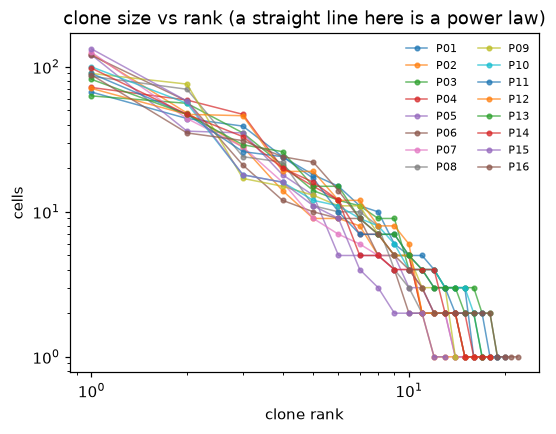

In [4]:
# the clone size distribution, which is what "heavy-tailed" means concretely
fig, ax = plt.subplots(figsize=(5.5, 4))
for patient, s in sizes.groupby(level=0):
    v = np.sort(s.to_numpy())[::-1]
    ax.plot(np.arange(1, len(v) + 1), v, marker="o", ms=3, lw=1, alpha=0.7, label=patient)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("clone rank"); ax.set_ylabel("cells")
ax.set_title("clone size vs rank (a straight line here is a power law)")
ax.legend(fontsize=7, ncol=2, frameon=False)
plt.show()

### Preprocessing

`group_singletons` collapses clones below a size threshold into one pooled id *per group*.
On a heavy-tailed repertoire most clones are tiny, and a clone seen once carries no
information about its own phenotype distribution while still counting as a row in every
entropy normalizer. Pooling is one defensible answer; dropping them is another. This
notebook keeps every clone and only shows what the call would do.

(`tcri.pp` also has `clone_size`, but it reads the registry that `to_anndata` writes, so it
runs *after* fitting rather than here — it appears in section 2.)

In [5]:
preview = adata.copy()
tcri.pp.group_singletons(preview, clonotype_key="clone_id", groupby="patient",
                         target_col="clone_id_grouped", min_clone_size=5)
print(f"clones: {adata.obs['clone_id'].nunique()} -> "
      f"{preview.obs['clone_id_grouped'].nunique()} if clones with <5 cells were pooled")

clones: 295 -> 232 if clones with <5 cells were pooled


## 2. Register and fit

`setup_anndata` names the columns the model needs. Two of them are easy to confuse and mean
entirely different things, even when they are the same column:

- **`batch_key`** is a *modelling* choice — one-hot encoded into every hidden layer of the
  encoder and decoder, so the network can absorb batch structure.
- **`replicate`** is a *statistical* choice — the independent unit. Registering it once lets
  `groupby` be left implicit on every metric, and the effective value still lands in each
  result's provenance rather than a `None` placeholder.

In [6]:
pyro.clear_param_store()
TCRIModel.setup_anndata(
    adata,
    layer="counts",
    clonotype_key="clone_id",
    phenotype_key="phenotype",
    covariate_key="condition",   # the axis a delta is taken across
    batch_key="patient",         # one-hot into the networks
    replicate="patient",         # the independent unit for statistics
)

model = TCRIModel(adata, n_latent=10, n_hidden=64, n_layers=2,
                  classifier_n_layers=1, classifier_hidden=64, K=4, seed=SEED)

with contextlib.redirect_stdout(io.StringIO()):
    model.train(max_epochs=150, batch_size=256, accelerator="cpu",
                enable_progress_bar=False, enable_model_summary=False)
    model.to_anndata(adata)
    # The permutation references, fitted once. Every scored metric below is read against one:
    # the same model, the same knobs, the same seed, on one permuted label vector. Without
    # them a metric raises rather than reporting a bare number.
    tcri.null.all(model, adata, enable_progress_bar=False, enable_model_summary=False)

# what actually happened, not what was requested -- early stopping can end a run short
record = model.training_record_
pd.Series({k: v for k, v in record.items()
           if not hasattr(v, "__len__") or isinstance(v, str)}).to_frame("value")

,value
epochs_run,150
warmup_steps_taken,4500
n_steps_kl_warmup,2000
steps_per_epoch,30.0
ramp_completes_at_epoch,66.666667
ramp_completed,True
selection_criterion,objective_validation_percell
selected_epoch,117
selected_score,2.1429
stopped_early,False


`to_anndata` wrote everything the metrics read. Two model outputs are useful directly:
`predict` gives per-cell phenotype probabilities, and `get_latent_representation` gives the
latent embedding you would hand to a neighbours graph or a UMAP.

In [7]:
# `clone_size` reads uns[METADATA]['clone_col'], which to_anndata just wrote
tcri.pp.clone_size(adata, key_added="clone_size")
print(adata.obs[["clone_size"]].describe().round(1).T.to_string())

probs = model.predict(adata)
latent = model.get_latent_representation(adata)
print(f"predict : {probs.shape}  columns = {list(probs.columns)}")
print(f"latent  : {latent.shape}")
print(f"\nagreement between argmax(predict) and the observed label: "
      f"{(probs.to_numpy().argmax(1) == adata.obs['phenotype'].cat.codes.to_numpy()).mean():.1%}")
probs.head().round(3)

             count   mean   std  min   25%   50%    75%    max
clone_size  8320.0  101.1  75.7  1.0  30.0  94.0  164.0  261.0
predict : (8320, 4)  columns = ['phen_0', 'phen_1', 'phen_2', 'phen_3']
latent  : (8320, 10)

agreement between argmax(predict) and the observed label: 51.8%


,phen_0,phen_1,phen_2,phen_3
P01_pre_0,0.211,0.224,0.211,0.355
P01_pre_1,0.233,0.314,0.213,0.239
P01_pre_2,0.233,0.314,0.213,0.239
P01_pre_3,0.211,0.224,0.211,0.355
P01_pre_4,0.135,0.258,0.471,0.136


## 3. Diagnostics — before trusting any metric

`tcri.diag` asks whether the *fit* is worth interpreting. Every function returns a
DataFrame, so the numbers are inspectable and not only drawn.

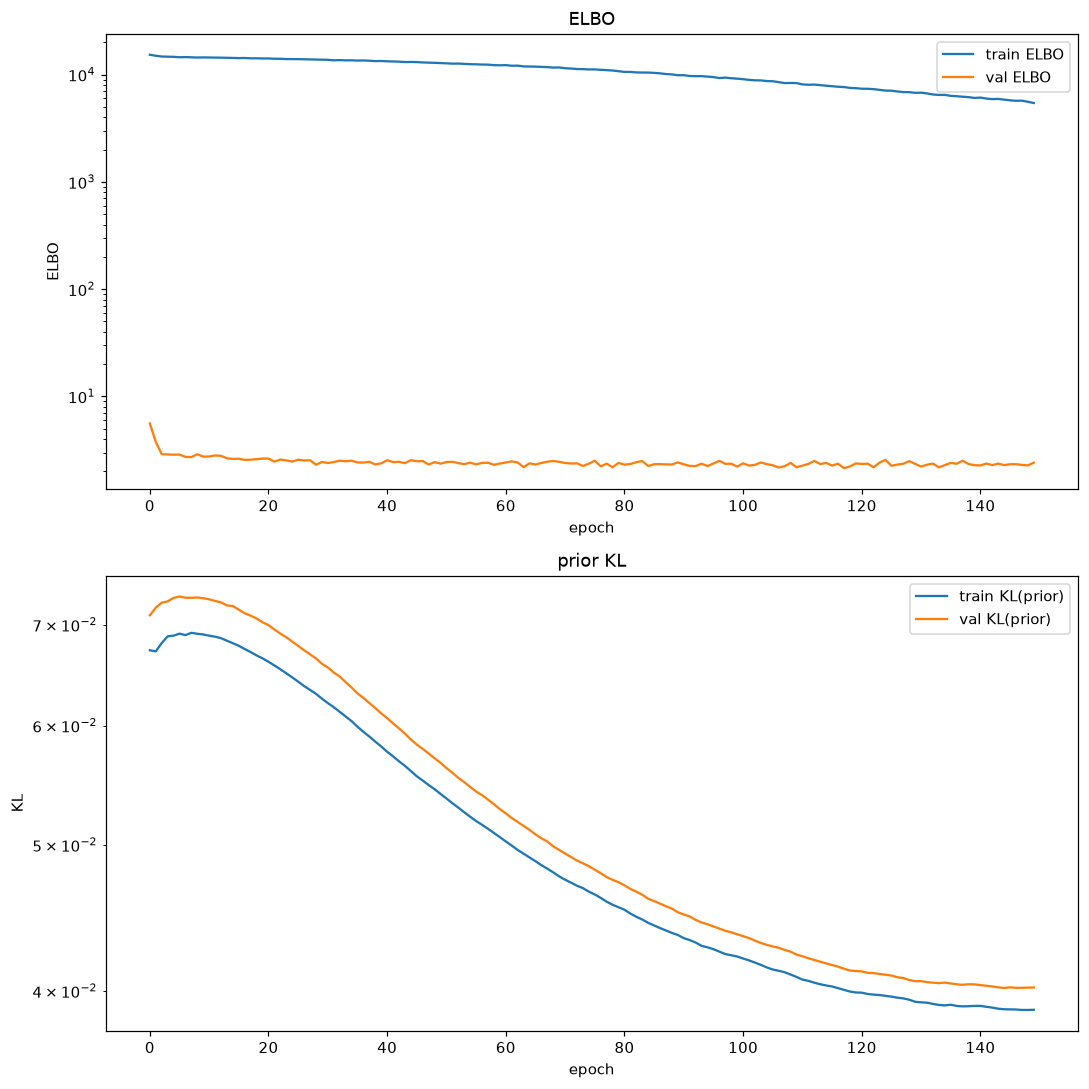

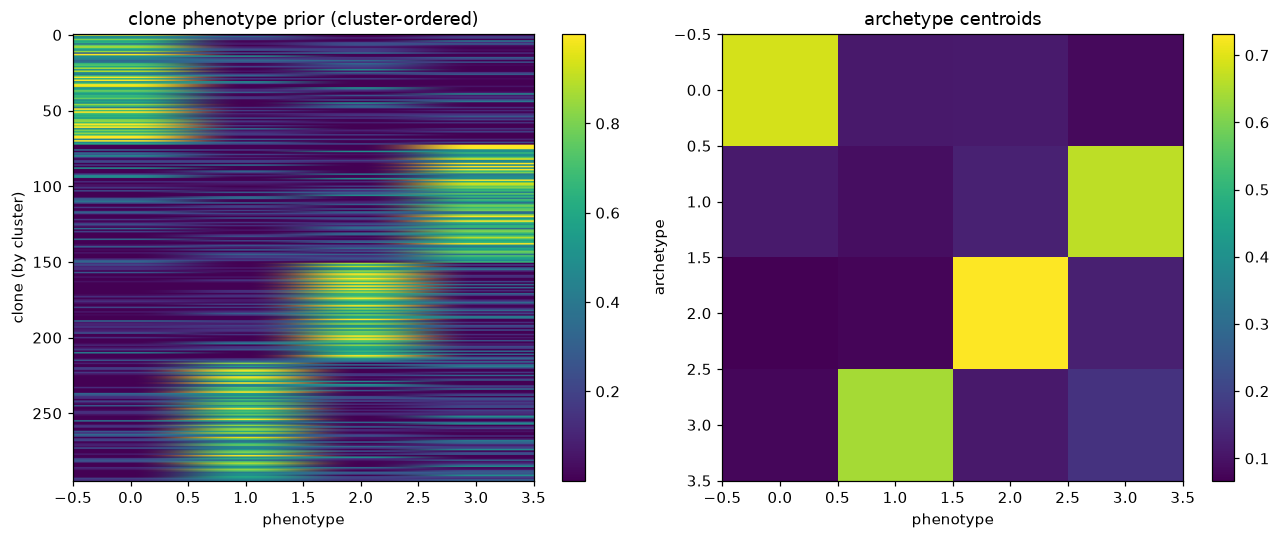

In [8]:
# did training converge, and did the VampPrior components separate?
tcri.diag.loss(model, log_scale=True)
plt.show()
tcri.diag.archetypes(model)
plt.show()

**`joint_distribution_ppc`** — does the model's clone×phenotype table resemble the observed
crosstab? Per-clone L1 distance, where 0 is perfect and 2 is maximal.

In [9]:
ppc = tcri.diag.joint_distribution_ppc(adata, distance_metric="l1")
print(f"median per-clone L1: {ppc['distance'].median():.3f}")
ppc.head()

median per-clone L1: 0.504


,covariate,clonotype,distance
0,pre,clone_0@P01,0.085165
1,pre,clone_0@P02,1.300111
2,pre,clone_0@P03,0.287049
3,pre,clone_0@P04,0.194006
4,pre,clone_0@P05,0.420380


**`phenotype_calibration`** — when the classifier says 0.8, is it right 80% of the time?
`ECE` is the expected calibration error; lower is better.

ECE = 0.104


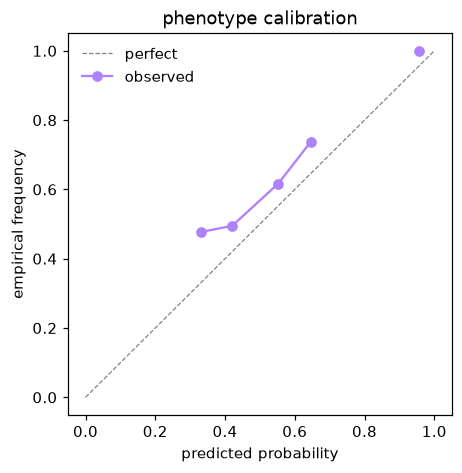

In [10]:
calib = tcri.diag.phenotype_calibration(adata, n_bins=8)
print(f"ECE = {calib.attrs['ECE']:.3f}")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.plot([0, 1], [0, 1], ls="--", lw=0.8, c="0.5", label="perfect")
ax.plot(calib["mean_pred"], calib["emp_freq"], marker="o", color="#AE81FF", label="observed")
ax.set_xlabel("predicted probability"); ax.set_ylabel("empirical frequency")
ax.set_title("phenotype calibration"); ax.legend(frameon=False)
plt.show()

**`reconstruction_ppc`** — does the decoder generate counts like the real ones?
**`permutation_null`** — how large is the metric under shuffled labels? This is the
reference any MI should be read against, and it is *model-free*: it scores the empirical
crosstab and draws no posterior samples.

In [11]:
recon = tcri.diag.reconstruction_ppc(model, adata, n_sims=25, random_state=SEED)
print("reconstruction PPC:")
print(recon.round(3).to_string(index=False))

null = tcri.diag.permutation_null(adata, metric="mutual_information", covariate="post",
                                  n_perm=200, random_state=SEED)
print("\npermutation null — `observed` is the real labels, `null_mean` is shuffled:")
print(null[["covariate", "observed", "null_mean", "null_sd", "z", "p"]]
      .round(4).to_string(index=False))

reconstruction PPC:
          statistic  observed  simulated  discrepancy
  mean_library_size  1328.766   1327.125        1.641
median_library_size  1278.000   1279.200        1.200
   dropout_fraction     0.000      0.001        0.001
    mean_expression    33.219     33.178        0.041
     var_expression   222.277    279.812       57.535

permutation null — `observed` is the real labels, `null_mean` is shuffled:
covariate  observed  null_mean  null_sd        z     p
     post    0.4747     0.0829   0.0033 117.7877 0.005


## 4. `tl` — compute once, cached with provenance

Every `tl` returns the **same three slots** and stores that object in `uns`:

| slot | one row per | reduced over |
|---|---|---|
| `table` | (covariate, group, item, draw) | nothing — the substrate |
| `result` | (covariate, group, item) | `draw` only |
| `stats` | (split_a, split_b) | items → groups, then contrast |

`result` is built *from* `table`, so the two cannot drift. `stats` appears only when
`splitby` is set, and its **n counts replicates, never items** — 18 clones from 4 patients
give n=4, not n=18.

In [12]:
mi_post = tcri.tl.mutual_information(
    adata,
    covariate="post",
    groupby="patient",     # could be omitted -- `replicate` is registered
    splitby="disease_status",    # -> produces `stats`
    n_samples=100,         # posterior draws; 0 = plug-in point estimate
    normalize_mode="min",  # "average" is the manuscript's eq 6
    weighted=False,        # one vote per CLONE; True = one vote per CELL
    random_state=SEED,
)
print("slots:", sorted(mi_post))
mi_post["result"][["patient", "disease_status", "value", "sd", "hdi_low", "hdi_high"]].round(4)

slots: ['result', 'stats', 'table']


,patient,disease_status,value,sd,hdi_low,hdi_high
0,P01,disease,0.4098,0.0227,0.3663,0.4427
1,P02,disease,0.4336,0.0225,0.3962,0.4785
2,P03,disease,0.4724,0.0165,0.4411,0.4985
3,P04,disease,0.4279,0.0234,0.3925,0.4857
4,P05,disease,0.4720,0.0142,0.4444,0.4933
5,P06,disease,0.4604,0.0234,0.4227,0.5056
6,P07,disease,0.5063,0.0167,0.4827,0.5466
7,P08,disease,0.5257,0.0192,0.4870,0.5549
8,P09,control,0.2270,0.0221,0.1809,0.2614
9,P10,control,0.3423,0.0197,0.3035,0.3789


In [13]:
# the contrast. `n_a`/`n_b` count PATIENTS -- that is what makes pseudoreplication impossible
mi_post["stats"][["level_a", "level_b", "n_a", "n_b", "mean_a", "mean_b",
                  "delta", "p", "stars"]].round(4)

,level_a,level_b,n_a,n_b,mean_a,mean_b,delta,p,stars
0,control,disease,8,8,0.335,0.4635,0.1285,0.0002,***


**`n_clones_ref` matters here.** This cohort has ragged clone counts by design, and
`clonotypic_entropy` normalizes by `log2(C)` where `C` is that group's own supported clone
count. Two patients with different `C` are therefore on different scales. Passing
`n_clones_ref` pins one denominator for everyone.

In [14]:
free = tcri.tl.clonotypic_entropy(adata, covariate="post", groupby="patient",
                                  random_state=SEED, inplace=False)["result"]
pinned = tcri.tl.clonotypic_entropy(adata, covariate="post", groupby="patient",
                                    n_clones_ref=int(adata.obs.groupby("patient", observed=True)
                                                     ["clone_id"].nunique().max()),
                                    random_state=SEED, inplace=False)["result"]
comparison = (free.groupby("patient", observed=True)["value"].mean().rename("own log2(C)")
              .to_frame()
              .join(pinned.groupby("patient", observed=True)["value"].mean().rename("pinned")))
comparison["difference"] = comparison["pinned"] - comparison["own log2(C)"]
comparison.round(4).head(8)

,own log2(C),pinned,difference
patient,,,
P01,0.8641,0.8115,-0.0527
P02,0.8471,0.7654,-0.0817
P03,0.8336,0.7964,-0.0372
P04,0.8559,0.7568,-0.0991
P05,0.8335,0.8094,-0.0242
P06,0.8362,0.7394,-0.0968
P07,0.8102,0.7321,-0.0781
P08,0.8197,0.7832,-0.0365


In [15]:
# the other metrics, plus the joint they all reduce
jd = tcri.tl.joint_distribution(adata, covariate="post", n_samples=20, random_state=SEED)
print(f"joint: {jd['result'].shape} (clone x phenotype), rows sum to 1: "
      f"{np.allclose(jd['result'].sum(axis=1), 1.0)}")

tcri.tl.clonotypic_entropy(adata, covariate="post", groupby="patient", splitby="disease_status",
                           n_samples=60, random_state=SEED)
tcri.tl.phenotypic_entropy(adata, covariate="post", groupby="patient", splitby="disease_status",
                           n_samples=60, random_state=SEED)
tcri.tl.phenotypic_flux(adata, cov_from="pre", cov_to="post", groupby="patient",
                        splitby="disease_status", distance_metric="kl",
                        n_samples=60, random_state=SEED)

# a second call REPLACES the cached result (the scanpy convention). `key_added` keeps both.
tcri.tl.mutual_information(adata, covariate="pre", groupby="patient", splitby="disease_status",
                           n_samples=100, random_state=SEED, key_added="mi_pre")

pre_vs_post = pd.concat([
    tcri.get.result(adata, "mutual_information", key="mi_pre")["result"].assign(condition="pre"),
    mi_post["result"].assign(condition="post"),
])
pre_vs_post.groupby(["disease_status", "condition"], observed=True)["value"].mean().unstack("condition").round(4)

joint: (283, 4) (clone x phenotype), rows sum to 1: True


condition,post,pre
disease_status,,
control,0.3350,0.3586
disease,0.4635,0.4396


### Reading results back

`tcri.get` is how anything reads a cached result without knowing the storage format — `pl`
uses it, and so should your own code. `params` carries every argument the tool ran with,
including defaults that were never passed, so a figure from six months ago can still say
what produced it.

In [16]:
assert tcri.get.result(adata, "mutual_information")["result"].equals(mi_post["result"])
params = tcri.get.params(adata, "mutual_information")
print({k: params[k] for k in ("covariate", "groupby", "splitby", "n_samples",
                              "normalize_mode", "weighted")})

# the unreduced substrate: one row per draw
tcri.get.table(adata, "mutual_information", which="table").head().round(4)

{'covariate': 'post', 'groupby': 'patient', 'splitby': 'disease_status', 'n_samples': 100, 'normalize_mode': 'min', 'weighted': False}


,covariate,patient,disease_status,draw,value
0,post,P01,disease,0,0.4410
1,post,P01,disease,1,0.4271
2,post,P01,disease,2,0.4182
3,post,P01,disease,3,0.4299
4,post,P01,disease,4,0.4019


## 5. `pl` — twins that render the cache

A `pl` twin takes **no metric arguments**. It reads what `tl` stored, so the covariate,
groupby, splitby and n_samples it draws are the ones actually used — a figure cannot
disagree with the frame in your hand. Run the `tl` twin first.

The mark follows one rule: **a mark shows one variance component.** Within an x position
the sample is the coarsest unit that varies there (replicate > item > draw). So the dots are
patients wherever a p-value over patients sits above them, and draws are never pooled across
replicates.

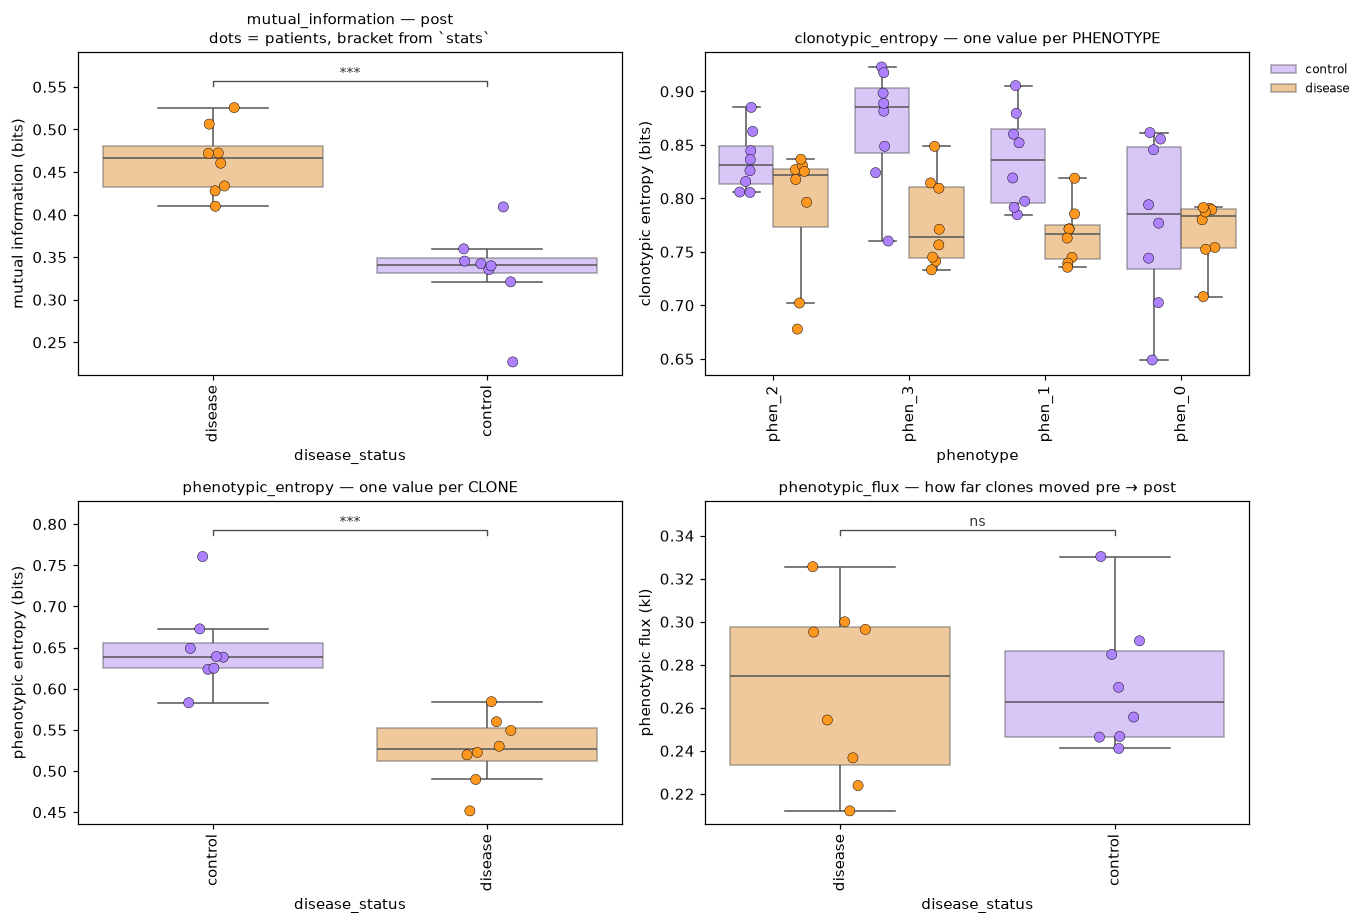

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5))
tcri.pl.mutual_information(adata, ax=axes[0, 0])
axes[0, 0].set_title("mutual_information — post\ndots = patients, bracket from `stats`", fontsize=10)
tcri.pl.clonotypic_entropy(adata, ax=axes[0, 1])
axes[0, 1].set_title("clonotypic_entropy — one value per PHENOTYPE", fontsize=10)
tcri.pl.phenotypic_entropy(adata, ax=axes[1, 0])
axes[1, 0].set_title("phenotypic_entropy — one value per CLONE", fontsize=10)
tcri.pl.phenotypic_flux(adata, ax=axes[1, 1])
axes[1, 1].set_title("phenotypic_flux — how far clones moved pre → post", fontsize=10)
fig.tight_layout()
plt.show()

### Colours are a property of the level

`resolve_colors` caches under scanpy's `uns["<key>_colors"]`, so a level keeps its colour in
every later figure — and `sc.pl.umap(color="disease_status")` matches too.

In [18]:
palette = tcri.pl.resolve_colors(adata, "disease_status", palette={"disease": "#2E8B57", "control": "#C1440E"})
print("disease_status palette:", palette)
print("stored in uns   :", adata.uns[K.colors("disease_status")])

disease_status palette: {'control': '#c1440e', 'disease': '#2e8b57'}
stored in uns   : ['#c1440e', '#2e8b57']


## 6. The paired entropies — what changed, per clone

`delta_*` takes `cov_from`/`cov_to` and subtracts **within a posterior draw**, so the
reported interval is the interval of the *difference*. HDIs do not subtract — you cannot
recover it from the endpoints' intervals, which is why this is a function rather than
arithmetic you do yourself.

Support is the **intersection**: clones present at both conditions, within each patient. A
delta needs both endpoints, and the drop is warned about because it moves `n`.

There is deliberately **no `delta_mutual_information`** — MI has no item axis, so it is
already the repertoire-level number and its "delta" is a subtraction of two cached scalars.
That one belongs to you, not the package.

In [19]:
d_phen = tcri.tl.delta_phenotypic_entropy(
    adata, cov_from="pre", cov_to="post", groupby="patient", splitby="disease_status",
    n_samples=60, random_state=SEED)
d_clon = tcri.tl.delta_clonotypic_entropy(
    adata, cov_from="pre", cov_to="post", groupby="patient", splitby="disease_status",
    n_samples=60, random_state=SEED)

print("Δ phenotypic entropy (post − pre), per arm:")
print(d_phen["result"].groupby("disease_status", observed=True)["value"]
      .agg(["mean", "count"]).round(4).to_string())
d_phen["stats"][["level_a", "level_b", "n_a", "n_b", "delta", "p", "stars"]].round(4)

Δ phenotypic entropy (post − pre), per arm:
                  mean  count
disease_status               
control        -0.0021    130
disease        -0.0004    136


,level_a,level_b,n_a,n_b,delta,p,stars
0,control,disease,8,8,0.0017,0.2345,ns


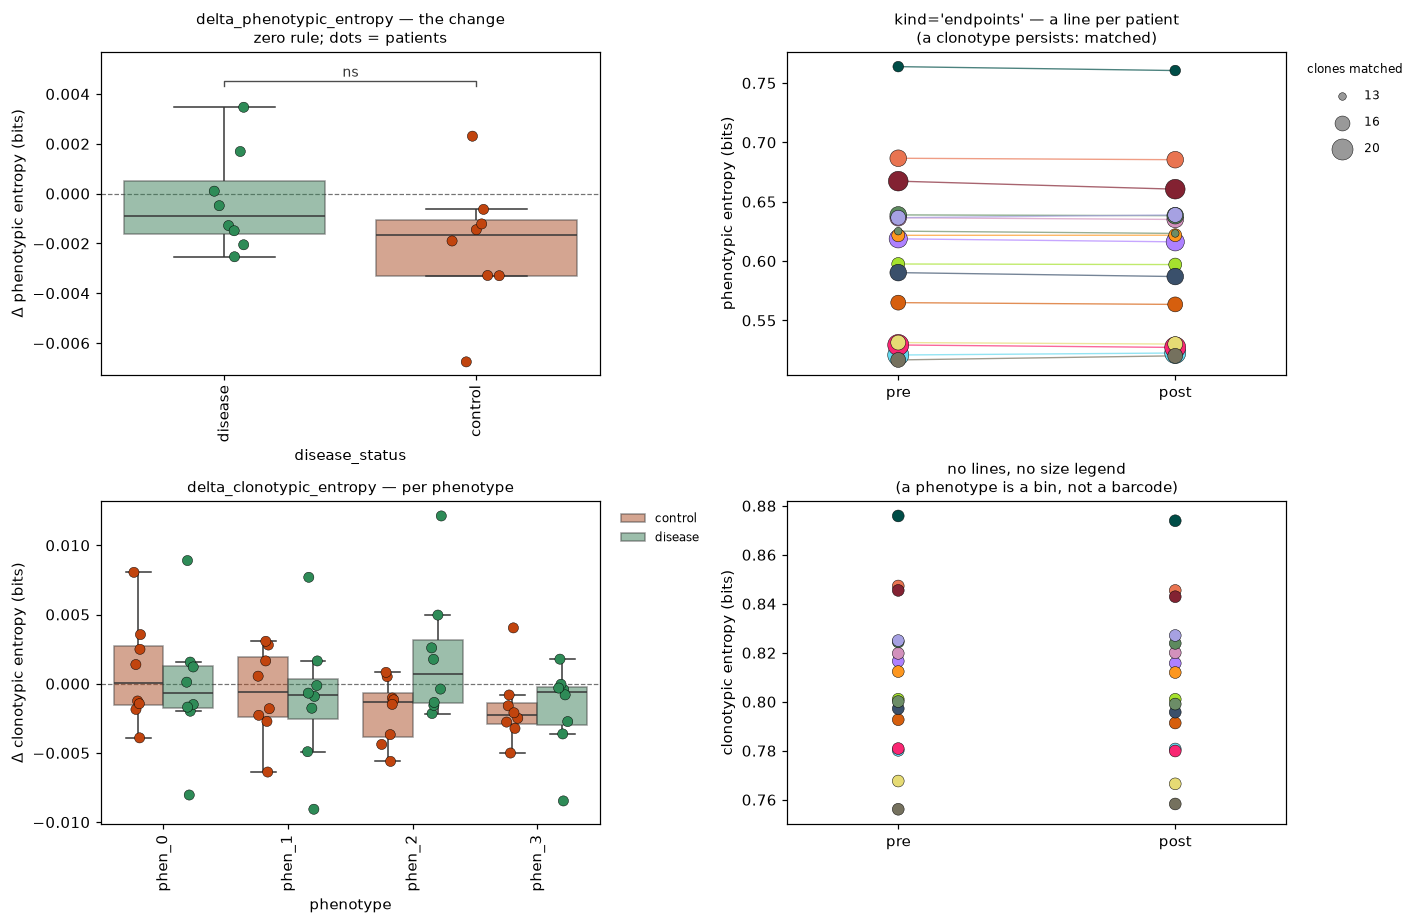

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
tcri.pl.delta_phenotypic_entropy(adata, kind="delta", ax=axes[0, 0])
axes[0, 0].set_title("delta_phenotypic_entropy — the change\nzero rule; dots = patients", fontsize=10)
tcri.pl.delta_phenotypic_entropy(adata, kind="endpoints", ax=axes[0, 1])
axes[0, 1].set_title("kind='endpoints' — a line per patient\n(a clonotype persists: matched)", fontsize=10)
tcri.pl.delta_clonotypic_entropy(adata, kind="delta", ax=axes[1, 0])
axes[1, 0].set_title("delta_clonotypic_entropy — per phenotype", fontsize=10)
tcri.pl.delta_clonotypic_entropy(adata, kind="endpoints", ax=axes[1, 1])
axes[1, 1].set_title("no lines, no size legend\n(a phenotype is a bin, not a barcode)", fontsize=10)
fig.tight_layout()
plt.show()

## 7. Saving and resuming

`ut.save_tcri_session` writes the fitted model, its pyro parameter store and the AnnData
together, so a later session picks up exactly where this one stopped — including every
cached `tl` result, since those live in `uns`.

In [21]:
import tempfile

with tempfile.TemporaryDirectory() as tmp:
    manifest = tcri.ut.save_tcri_session(model, adata, f"{tmp}/run")
    print("wrote:", sorted(manifest))

    reloaded_model, reloaded = tcri.ut.load_tcri_session(f"{tmp}/run")
    cached = tcri.get.result(reloaded, "mutual_information")["result"]
    print(f"\nreloaded {reloaded.n_obs} cells")
    print(f"cached MI survived the round trip: "
          f"{np.allclose(cached['value'], mi_post['result']['value'])}")
    print(f"provenance survived: {tcri.get.params(reloaded, 'mutual_information')['covariate']!r}")

wrote: ['adata', 'meta', 'model_dir', 'pyro', 'setup']

reloaded 8320 cells
cached MI survived the round trip: True
provenance survived: 'post'
